In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [ ]:
#DATA LOADING & CLEANING
oct19_df=pd.read_csv("/content/2019-Oct.csv")
oct19_df.head()
len(oct19_df)


2996650

In [ ]:
nov19_df=pd.read_csv("/content/2019-Nov.csv")
nov19_df.head()
print(nov19_df.shape)

(3010821, 9)


In [ ]:
dec19_df=pd.read_csv("/content/2019-Dec.csv")
dec19_df.head()
print(dec19_df.shape)

(2960504, 9)


In [ ]:
jan20_df=pd.read_csv("/content/2020-Jan.csv")
jan20_df.head()
print(jan20_df.shape)

(2986296, 9)


In [ ]:
feb20_df=pd.read_csv("/content/2020-Feb.csv")
feb20_df.head()
print(feb20_df.shape)

(2959538, 9)


In [ ]:
df=pd.concat([oct19_df,nov19_df,dec19_df,jan20_df,feb20_df],ignore_index=True)
df.head()
print(df.shape)

(14913809, 9)


In [ ]:
df.isnull().sum()

,0
event_time,0
event_type,2
product_id,2
category_id,2
category_code,14659343
brand,6314570
price,2
user_id,2
user_session,3128


In [ ]:
df.drop(columns=['category_code'],inplace=True)

In [ ]:
df['brand'].fillna('Unknown',inplace=True)

/tmp/ipykernel_16563/1677439700.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['brand'].fillna('Unknown',inplace=True)


In [ ]:
df.dropna(subset=['user_session'],inplace=True)

In [ ]:
df['event_time'] = pd.to_datetime(df['event_time'])
df['date'] = df['event_time'].dt.date

In [ ]:
df.isnull().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
brand,0
price,0
user_id,0
user_session,0
date,0


In [ ]:
#EDA ANALYSIS
df.head()

,event_time,event_type,product_id,category_id,brand,price,user_id,user_session,date
0,2019-10-01 00:00:00+00:00,cart,5773203.0,1.487580e+18,runail,2.62,463240011.0,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01
1,2019-10-01 00:00:03+00:00,cart,5773353.0,1.487580e+18,runail,2.62,463240011.0,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01
2,2019-10-01 00:00:07+00:00,cart,5881589.0,2.151191e+18,lovely,13.48,429681830.0,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01
3,2019-10-01 00:00:07+00:00,cart,5723490.0,1.487580e+18,runail,2.62,463240011.0,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10-01
4,2019-10-01 00:00:15+00:00,cart,5881449.0,1.487580e+18,lovely,0.56,429681830.0,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01


In [ ]:
df.shape

(14910681, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14910681 entries, 0 to 14913808
Data columns (total 9 columns):
 #   Column        Dtype              
---  ------        -----              
 0   event_time    datetime64[ns, UTC]
 1   event_type    object             
 2   product_id    float64            
 3   category_id   float64            
 4   brand         object             
 5   price         float64            
 6   user_id       float64            
 7   user_session  object             
 8   date          object             
dtypes: datetime64[ns, UTC](1), float64(4), object(4)
memory usage: 1.1+ GB


In [ ]:
df.describe()

,product_id,category_id,price,user_id
count,1.491068e+07,1.491068e+07,1.491068e+07,1.491068e+07
mean,5.479907e+06,1.554087e+18,8.588385e+00,5.205348e+08
std,1.312723e+06,1.689106e+17,1.946792e+01,8.687423e+07
min,3.752000e+03,1.487580e+18,-7.937000e+01,4.654960e+05
25%,5.724581e+06,1.487580e+18,2.060000e+00,4.813441e+08
50%,5.810082e+06,1.487580e+18,4.110000e+00,5.524542e+08
75%,5.857320e+06,1.487580e+18,7.140000e+00,5.777290e+08
max,5.930455e+06,2.242903e+18,3.277800e+02,6.182201e+08


In [ ]:
df.duplicated().sum()

np.int64(804914)

In [ ]:
df[df.duplicated()].head()

,event_time,event_type,product_id,category_id,brand,price,user_id,user_session,date
13,2019-10-01 00:00:30+00:00,remove_from_cart,5809103.0,1.487580e+18,irisk,0.60,429681830.0,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01
30,2019-10-01 00:01:05+00:00,remove_from_cart,5858981.0,1.487580e+18,de.lux,0.79,429681830.0,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01
36,2019-10-01 00:01:07+00:00,remove_from_cart,5312.0,1.487580e+18,runail,1.27,467916806.0,2f5b5546-b8cb-9ee7-7ecd-84276f8ef486,2019-10-01
38,2019-10-01 00:01:10+00:00,remove_from_cart,5823915.0,1.487580e+18,milv,1.59,429681830.0,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01
51,2019-10-01 00:01:24+00:00,remove_from_cart,5664641.0,1.487580e+18,Unknown,0.70,429681830.0,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10-01


In [ ]:
df[df['price']<0].value_counts().sum()

np.int64(92)

In [ ]:
df = df[df['price'] > 0]

In [ ]:
#FUNNEl
df['event_type'].value_counts()

,count
event_type,
view,6936778
cart,4142107
remove_from_cart,2843878
purchase,904739


In [ ]:
#CONVERSION
purchase = df[df['event_type']=='purchase'].shape[0]
view = df[df['event_type']=='view'].shape[0]

(purchase/view)*100

13.042640257479771

In [ ]:
#TOP PRODUCTS
df[df['event_type']=='purchase'].groupby('product_id')['price'].sum().sort_values(ascending=False).head(10)

,price
product_id,
5686313.0,0.29
4580.0,0.30
5745972.0,0.30
5552922.0,0.30
5552866.0,0.30
5880650.0,0.32
5812526.0,0.32
5902971.0,0.32
5762848.0,0.32


In [ ]:
#TOP BRANDS
df[df['event_type']=='purchase'].groupby('brand')['price'].sum().sort_values(ascending=False).head(10)

,price
brand,
Unknown,1820150.08
runail,250768.69
grattol,182873.46
irisk,156651.99
uno,133182.29
strong,107433.69
masura,95900.50
jessnail,94581.74
ingarden,88237.29


In [ ]:
#TIME ANALYSIS
df.groupby('date')['price'].sum().head(10)

,price
date,
2019-10-01,1224837.79
2019-10-02,1658929.82
2019-10-03,1103354.89
2019-10-04,959509.69
2019-10-05,919042.98
2019-10-06,1511935.66
2019-10-07,1495659.39
2019-10-08,1218829.44
2019-10-09,1197564.82


/tmp/ipykernel_16563/1659269201.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df[df['event_type']=='purchase'].groupby('Month')['price'].sum()


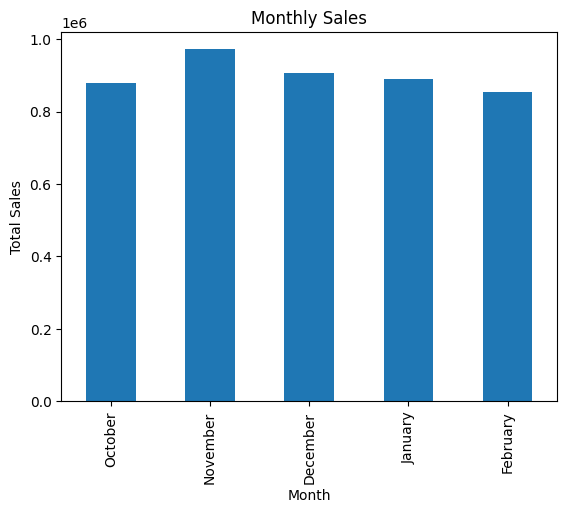

In [ ]:
#MONTHLY TRENDS
df['Month'] = df['event_time'].dt.month_name()
order=['October','November','December','January','February']
df['Month'] = pd.Categorical(df['Month'],categories=order,ordered=True)
monthly_sales = df[df['event_type']=='purchase'].groupby('Month')['price'].sum()
monthly_sales.plot(kind='bar',title='Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
#PEAK HOUR
df['Hour'] = df['event_time'].dt.hour
df.groupby('Hour').size()

,0
Hour,
0,151752
1,137386
2,149835
3,209129
4,292069
5,444637
6,598997
7,711551
8,777422


In [ ]:
#TOTAL SALES
total_sales = df.loc[df['event_type']=='purchase', 'price'].sum()
total_sales

np.float64(4500719.139999995)

In [ ]:
# CART ABANDONMENT
cart = df[df['event_type']=='cart'].shape[0]
purchase = df[df['event_type']=='purchase'].shape[0]

abandon_rate = ((cart - purchase) / cart) * 100
f"{abandon_rate:.2f}%"

'78.16%'

In [ ]:
#DATA SAMPLING FOR VISUALIZATON
df_sample=df.sample(100000,random_state=42)

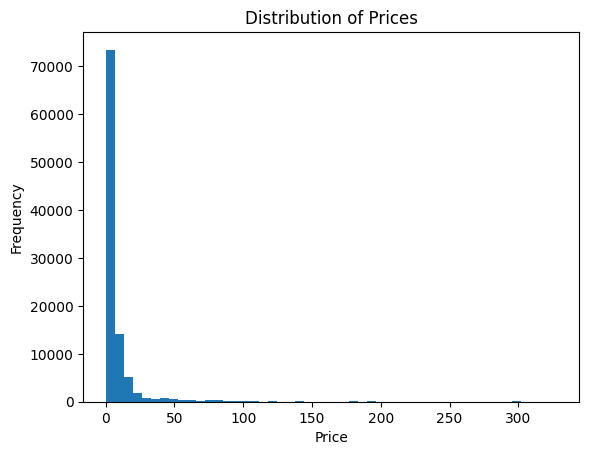

In [ ]:
df_sample['price'].plot(kind='hist', bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Prices')
plt.show()

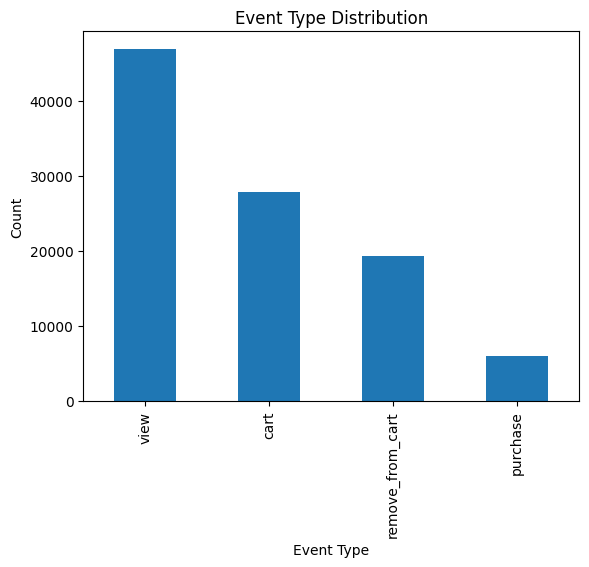

In [ ]:
df_sample['event_type'].value_counts().plot(kind='bar')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.title('Event Type Distribution')
plt.show()

**SUMMARY**

This project analyzed e-commerce event data to understand customer behavior, sales patterns, and product performance.

**FINDINGS**
*   Users mostly stay in the view stage, with lower conversion to purchase
*   Sales are concentrated in low to mid price range products, with a few high-value outliers
*  Clear skewed price distribution shows most items are affordable
*  Total sales is 4500719.14

*  The Abandonment Rate is 78.16%
* Most interactions in View stage
*  Certain brands and products dominate in terms of engagement and sales
*  Significant drop-off is observed between cart and purchase stages

**BUSINESS INSIGHTS**

The platform shows strong browsing activity but moderate conversion, indicating opportunity to improve purchase conversion and reduce cart abandonment.


**CONCLUSION**

This analysis helps understand customer journey, identify sales patterns, and highlights areas for improving conversion and revenue optimization.









**FINAL SUMMARY**

The analysis of the e-commerce event dataset shows that user behavior is heavily concentrated in the view stage, indicating strong browsing activity but lower progression towards purchase.
The price distribution is mostly concentrated in the lower range **(0–50)**, while total sales reach approximately **4,500,719, **showing revenue is driven by low to mid-value products with few high-value contributions.

The cart abandonment rate is **78.16%**, indicating a significant drop-off between cart and purchase stages. Overall conversion rate is **13.04%**, showing moderate efficiency in turning interactions into sales.

In terms of time behavior, user activity peaks around hour **3am –4 am**, indicating highest engagement during early hours. Monthly trends show highest interaction in November and December, followed by January, October, and February.

**Event distribution shows:**

Views: 6,936,778

Cart: 4,142,107

Remove from cart: 2,843,878

Purchases: 904,739

Top brand analysis shows most entries as unknown, but among identified brands, **Runail and Grattol** perform best in purchases.

Top product analysis indicates one dominant product ID **(5560754)** leading in interactions and sales.